
## __Super Store Data Analysis__

>#### _Introduction_
In this project, I performed Exploratory Data Analysis(EDA) on a Super Store Sales dataset to understand  how different factors influence sales and profit.
The analysis focuses on identifying sales trends, top-performing categories,customer segments, and the impat of discounts on profitability to gain useful insights about overall business performance.  

>#### _Objective_
The goal of this project is to explore Superstore sales data to identify sales trends, profitable product categories, customer segments, and the impact of discounts on profitability.

>#### _Tools Used_
- Python                                                                       
- Jupyter Notebook                                                             
- Pandas                                                                       
- Numpy                                                                        
- Matplotlib                                                                   
- Seaborn.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

>#### _Data Loading_
The dataset containing Super Store Sales information was loaded using the pandas library. 

In [38]:
# LOAD THE DATASET

df = pd.read_csv('superstore_orders.csv')

In [39]:
# CHECK DATASET PREVIEW

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [40]:
# CHECK DATASET STRUCTURE

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51289 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [41]:
# CHECK NUMBERS AND COLUMNS

df.shape

(51290, 21)

>#### _Data Understanding_
Understand dataset before Cleaning.

In [42]:
# CHECK COLUMNS

df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [43]:
# STATISTICAL SUMMARY

df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [44]:
# CHECK UNIQUE VALUES

df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales              2246
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
year                  4
dtype: int64

>#### _Data Cleaning_
Before performing analysis, the dataset was checked for errors and inconsistencies.                                                                     
Steps performed:
- Show for missing values.                                        

In [45]:
# FILLING MISSING VALUES

df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      1
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [46]:
# SHOW ROWS WITH MISSING VALUES

df[df.isnull().any(axis=1)]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
7,IN-2011-79397,03-01-2011,03-01-2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,NaN,276,1,0.1,110.412,125.32,Critical,2011


In [47]:
# DROP MISSING VALUES

df.dropna(inplace=True)

In [48]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [49]:
# FORMATTING ORDER DATE INTO DATE FORMAT

df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')

df['year'] = df['order_date'].dt.year

In [50]:
# CONVERTING SALES DATA TYPE INTO NUMERIC VALUE

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

> ### _Exploratory Data Analysis (EDA)_

#### **_Trend Analysis_**
CHART- 1.1 : **Sales Trend Overtime**                                          

This chart shows how total sales change over time, helping identify overall business growth patterns.

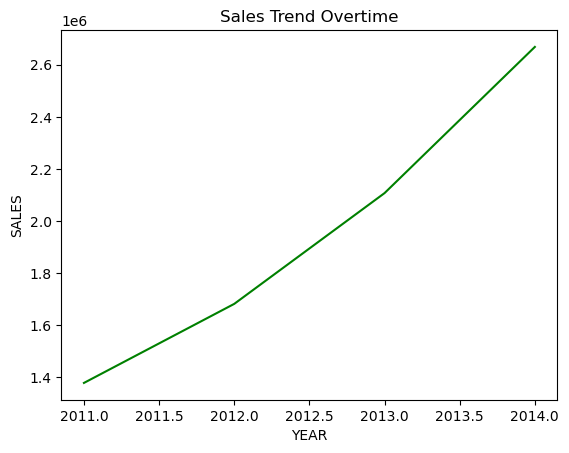

In [51]:
# SALES TRENDS OVERTIME

Sales_trend_overtime = df.groupby('year')['sales'].sum()
Sales_trend_overtime.plot(kind='line', color='green')

plt.xlabel('YEAR')
plt.ylabel('SALES')
plt.title('Sales Trend Overtime')

plt.show()

**Insights:**                                                                  
- Sales show an overall increasing trend over time.                            
- Some periods experience temporary drops in sales.                            
- Later years show higher sales compared to earlier periods.                   
- Indicates growing demand for products.

  #### _**Sales Analysis**_
 CHART- 2.1 : **Sales by Category**                                            
 
 This analysis shows how sales are distributed across different product categories.

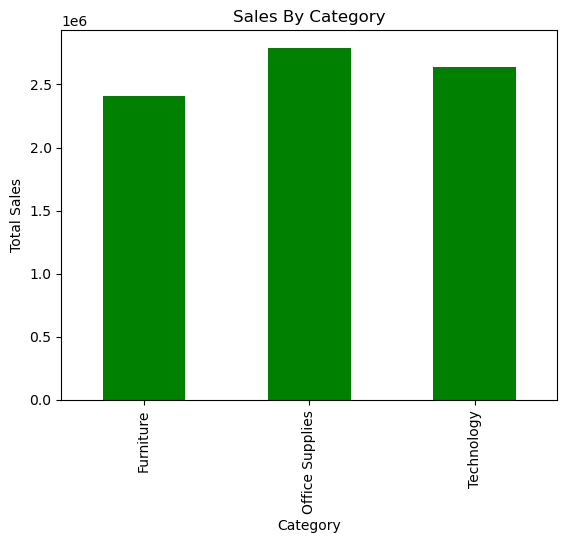

In [52]:
# SALES BY CATEGORY

sales_category = df.groupby('category')['sales'].sum()
sales_category.plot(kind = 'bar', color = 'Green')

plt.title("Sales By Category")
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

**Insights :**                                                                 

- Technology generates the highest sales.                                      
- Furniture contributes a moderate share of sales.                             
- Office Supplies have the lowest sales among categories.                      
- Technology products are the major revenue drivers.                           

 CHART- 2.2 : **Sales by segment**                                             
 
This chart analyzes sales distribution across different customer segments.

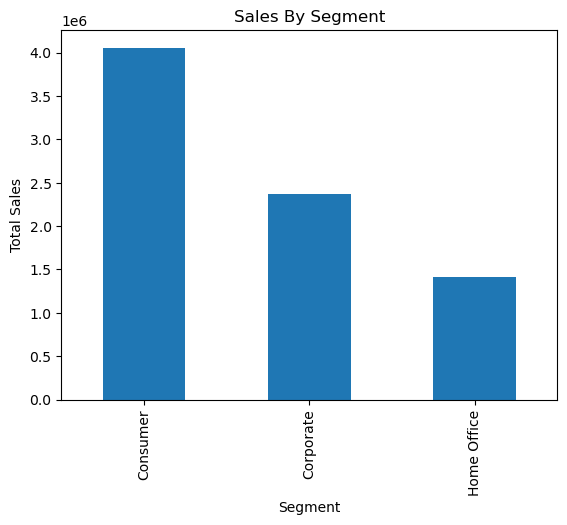

In [53]:
# SALES BY SEGMENT

sales_by_segment= df.groupby('segment')['sales'].sum()

ax = sales_by_segment.plot(kind = 'bar')

plt.title("Sales By Segment")
plt.xlabel('Segment')
plt.ylabel('Total Sales')

plt.show()

**Insights :**                                                                 
- Consumer segment contributes the highest sales.                              
- Corporate segment shows moderate sales.                                      
- Home Office segment contributes the least sales.                             
- Consumer customers are the primary buyers.

 CHART- 2.3 : **Monthly sales trend**                                          

This visualization shows how sales fluctuate across different months

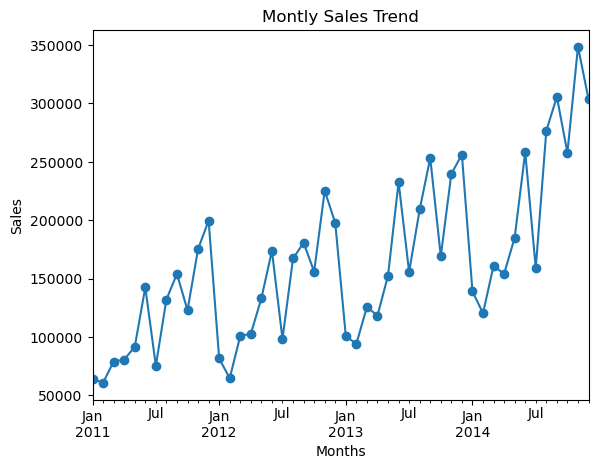

In [54]:
# MONTHLY SALES TREND
 
df['month']= df['order_date'].dt.to_period('M')

montly_sales = df.groupby('month')['sales'].sum()
montly_sales.plot(kind = 'line' , marker = 'o')

plt.title('Montly Sales Trend')
plt.xlabel('Months')
plt.ylabel('Sales')

plt.show()

**Insights**
- Sales vary across different months.                                          
- Some months show noticeable sales peaks.                                     
- Certain months experience lower sales levels.                                
- Indicates seasonal demand patterns.

#### **_Profit Analysis_**
CHART - 3.1 : **Profit by Category**                                           

This chart compares profit generated by each product category.

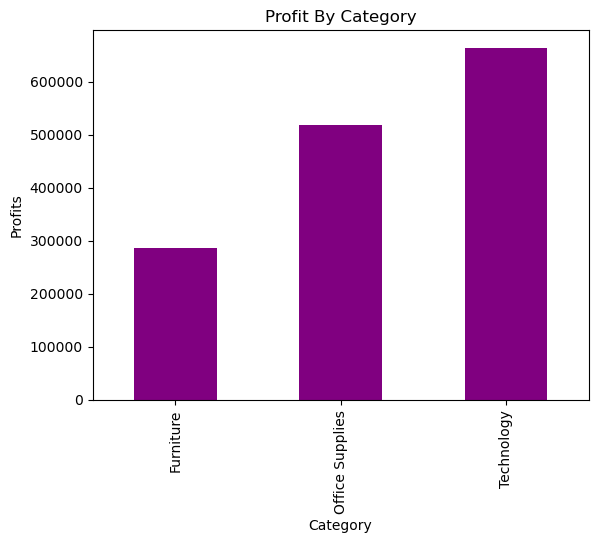

In [55]:
# PROFIT BY CATEGORY

df['profit'] = df['profit'].astype(float)

profit_by_category = df.groupby('category')['profit'].sum()
profit_by_category.plot(kind = 'bar', color= 'purple')

plt.title('Profit By Category')
plt.xlabel('Category')
plt.ylabel('Profits')

plt.show()

**Insights :**
- Technology category generates the highest profit.                            
- Office Supplies generate moderate profit.                                    
- Furniture category produces lower profit compared to others.                 
- Profit distribution varies across categories.

 CHART- 3.2 : **Profits By Sub-category**                                     
  
This analysis shows which product sub-categories generate the most profit.

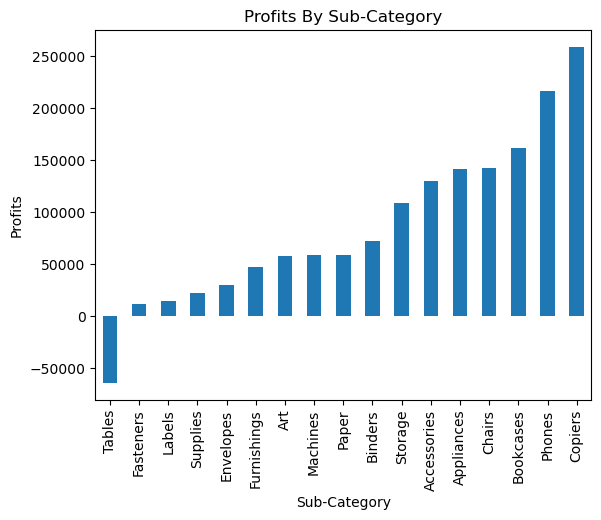

In [56]:
# PROFIT BY SUBCATEGORY

sub_category_profits = df.groupby('sub_category')['profit'].sum().sort_values()
sub_category_profits.plot(kind= 'bar')

plt.title("Profits By Sub-Category")
plt.xlabel('Sub-Category')
plt.ylabel('Profits')
plt.show()


**Insights**                                                                   
- Some sub-categories generate significantly higher profit.                    
- Certain sub-categories contribute minimal profit.                            
- Profit distribution is uneven across sub-categories.                         
- High-performing sub-categories drive profitability.


#### **_Discount Analysis_**
CHART - 4.1 : **Discount vs Profit**                                           

This scatter plot examines the relationship between discount levels and profit.

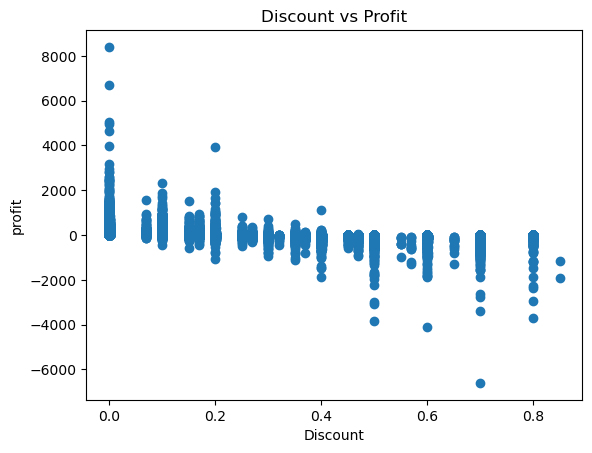

In [57]:
# DISCOUNT VS PROFIT

plt.scatter(df['discount'], df['profit'])

plt.title("Discount vs Profit")
plt.xlabel('Discount')
plt.ylabel('profit')

plt.show()

**Insights :**                                                                 
- Higher discounts tend to reduce profit.                                      
- Low discount levels often maintain better profit margins.                    
- Some high-discount transactions result in negative profit.                   
- Indicates discounts should be carefully controlled.

CHART - 4.2 : **Discount vs Sales**                                            

This chart analyzes the relationship between discount offered and sales generated.

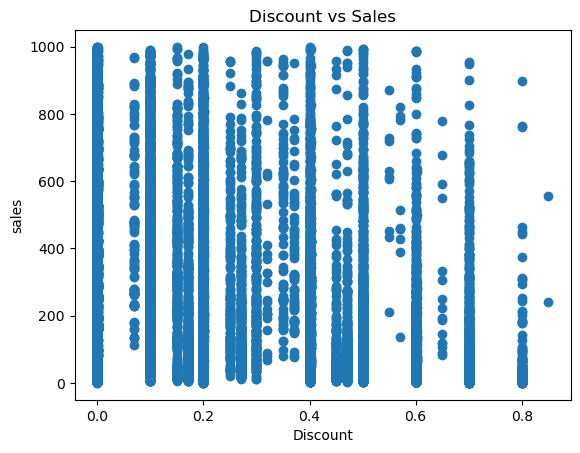

In [58]:
# DISCOUNT VS SALES

plt.scatter(df['discount'], df['sales'])

plt.title("Discount vs Sales")
plt.xlabel('Discount')
plt.ylabel('sales')

plt.show()


**Insights :**                                                                 
- Discounts sometimes increase sales volume.                                   
- However, higher discounts do not always guarantee higher sales.              
- Sales are influenced by other factors besides discount.                      
- Balanced discount strategies are important.

#### _**Top Products Analysis**_                                    
CHART - 5.1 : Top 10 products (sub-category) by sales                          

This chart highlights the sub-categories that generate the highest sales.

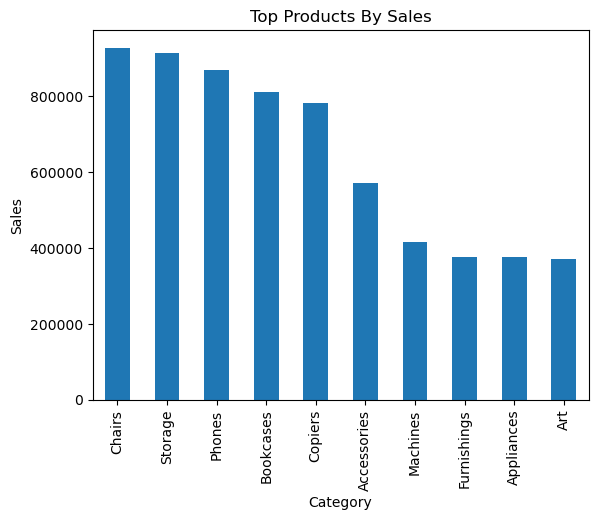

In [59]:
# TOP 10 PRODUCTS(SUB_CATEGORY) BY SALES 

top_products_by_sales = df.groupby('sub_category')['sales'].sum().sort_values(ascending = False)

top_products_by_sales.head(10).plot(kind = 'bar')

plt.title("Top Products By Sales")
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()


**Insights :**                                                                 
- A few sub-categories dominate total sales.                                   
- High-performing sub-categories significantly contribute to revenue.          
- These products are key revenue drivers.                                      
- Businesses can focus marketing on these products.

#### **_Regional Analysis_**                                                   
CHART - 6.1 : Profit by Region

This analysis compares profit generated across different geographical regions.

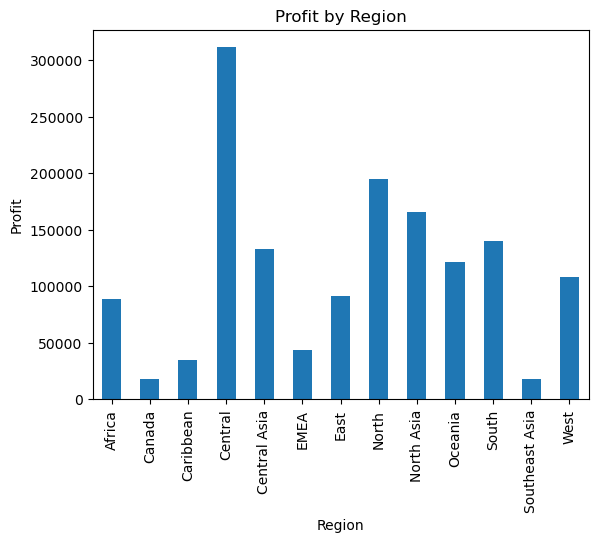

In [60]:
# PROFIT BY REGION

regional_profits = df.groupby('region')['profit'].sum()
regional_profits.plot(kind = 'bar')

plt.title("Profit by Region")
plt.xlabel('Region')
plt.ylabel('Profit')

plt.show()

**Insights :**                                                                 
- Some regions generate significantly higher profit.                           
- Other regions contribute moderate profit levels.                             
- Profit performance varies by region.                                         
- Regional demand influences profitability.

CHART - 6.2 : Sales by Region                                                  

This chart shows how sales are distributed across different regions.

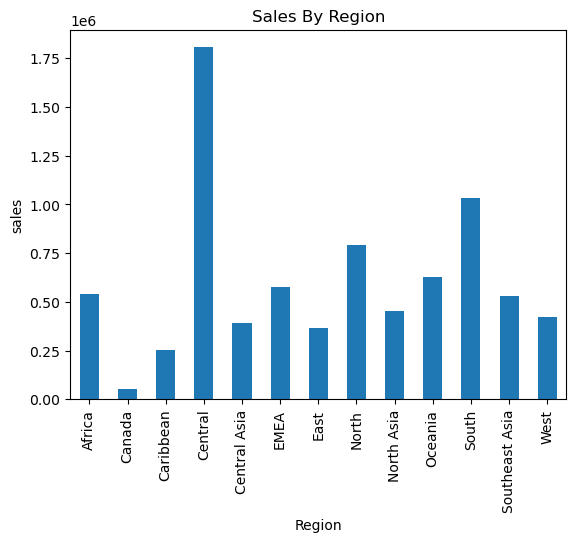

In [61]:
# SALES BY REGION
Regional_sales = df.groupby('region')['sales'].sum()
Regional_sales.plot(kind = 'bar')

plt.title('Sales By Region')
plt.xlabel('Region')
plt.ylabel('sales')

plt.show()

**Insights :**                                                                 
- Certain regions dominate total sales.                                        
- Some regions contribute moderate sales.                                      
- Regional differences affect overall revenue distribution.                    
- High-sales regions represent key markets.

#### _**Top Customer Analysis**_                                               
CHART - 7.1 : Top 10 Customer that generates large sales                                                  

This analysis identifies customers who contribute the highest sales.

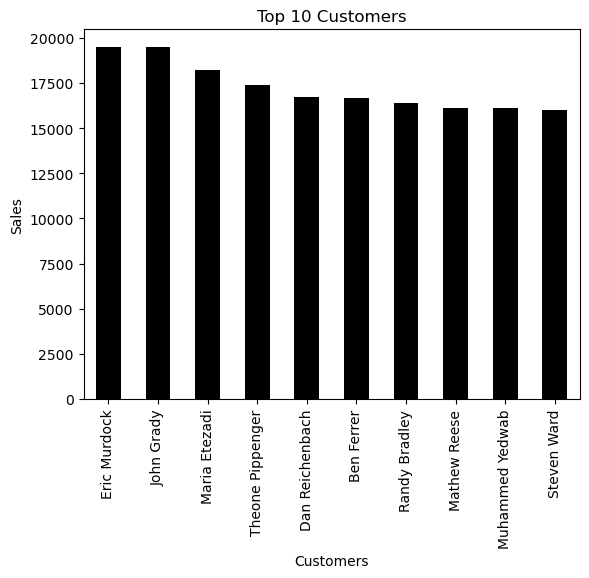

In [62]:
# TOP 10 CUSTOMERS

top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending= False)
top_customers.head(10).plot(kind = 'bar', color = 'black')

plt.title("Top 10 Customers")
plt.xlabel('Customers')
plt.ylabel('Sales')

plt.show()

**Insights :**                                                                 
- A small group of customers generates large sales volume.                     
- Top customers significantly impact total revenue.                            
- These customers are important for business growth.                           
- Maintaining strong relationships with them is beneficial.

#### _**Category Margin Analysis**_                                                                                                         
CHART - 8.1 : Profit margin Category                                                                                                        

The chart analyzes Average profit margin by each category.

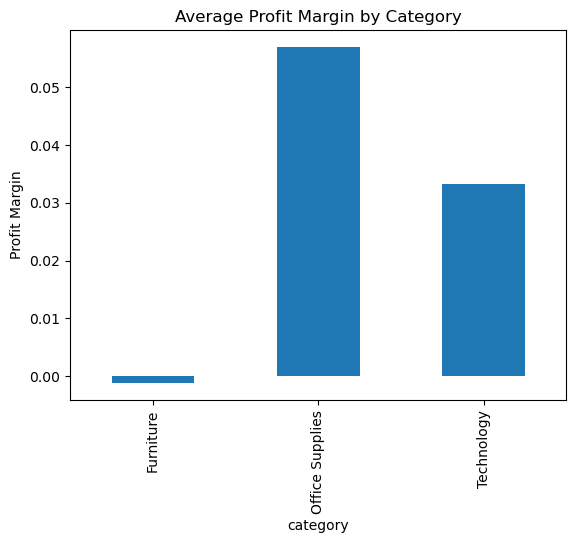

In [63]:
df['profit_margin'] = np.where(df['sales'] != 0, df['profit'] / df['sales'], np.nan)
category_margin = df.groupby('category')['profit_margin'].mean()

category_margin.plot(kind='bar')
plt.title('Average Profit Margin by Category')
plt.ylabel('Profit Margin')
plt.show()

**Insights :**                                                                                                                              
- Office Supplies has the highest profit margin, showing it generates the most profit compared to its sales.                                
- Technology has a moderate profit margin, meaning it is profitable but less than Office Supplies.                                          
- Furniture has a very low or negative profit margin, indicating possible losses or poor profitability in this category.

#### _**Correlation Analysis**_                                                
CHART - 9.1 : Correlation Heatmap of numeric columns                                             

The heatmap shows relationships between numerical variables in the dataset.

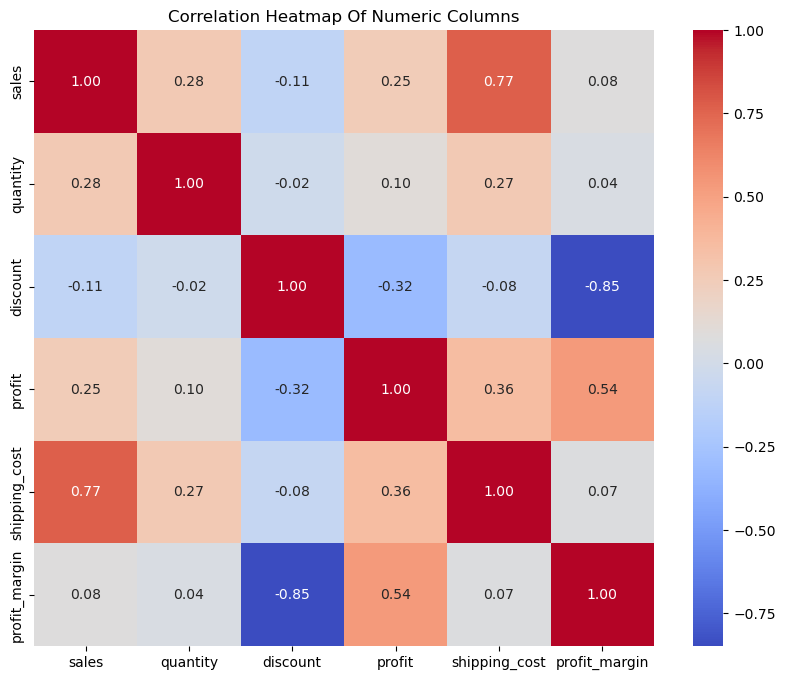

In [64]:
# CORRELATION HEATMAP OF NUMERIC (INT, FLOAT) COLUMNS

numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.title("Correlation Heatmap Of Numeric Columns")

plt.show()

**Insights :**                                                                 
- Sales and profit show positive correlation.                                  
- Discount has a negative relationship with profit.                            
- Higher discounts may reduce profitability.                                   
- Correlation helps understand relationships between variables.

>#### _Key Findings_                                                                                                                                                              

The most important insights discovered during the analysis.                                                                                                             

**Points:**                                                                                                                                                                       
- Technology category generates the highest sales.                                                                                                                                
- Consumer segment contributes the largest share of customers.                                                                                                                    
- Higher discounts often reduce profitability.                                                                                                                                    
- Some sub-categories generate high sales but low profit.                                                                                                                         
- Sales fluctuate across months indicating demand variations.

>#### _*Business Insights*_                                                                                                                                                       

**points:**                                                                                                                                                                       
- High-performing products should receive more marketing focus.                                                                                                                   
- Discount strategies should be carefully managed to avoid profit loss.                                                                                                           
- Regions with lower sales may require targeted marketing.                                                                                                                        
- Profitable categories should be prioritized in inventory planning.

>#### *_Conclusion_*                                                                                                                        

This analysis explored sales performance, profitability, customer segments, and regional trends using the Superstore dataset. The results highlight key factors affecting business performance, such as product demand and discount strategies. The insights gained from this analysis can help businesses make better decisions to improve sales and profitability.